<a href="https://colab.research.google.com/github/dikshi-shah/Automated-Retinopathy-Detection/blob/main/Crop_yield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [2]:
data = pd.read_csv('/content/Crop-yield Dataset.csv')
display(data.head(5))

,N,P,K,Soil_pH,Soil_Moisture,Soil_Type,Organic_Carbon,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Region,Altitude,Season,Crop_Type,Irrigation_Type,Fertilizer_Used,Pesticide_Used,Crop_Yield_ton_per_hectare
0,132,62,22,6.35,59.78,Clay,0.43,22.97,53.89,1305.68,7.73,15.96,Central,36,Rabi,Maize,Canal,223.48,23.36,11.42
1,122,71,66,5.98,25.54,Sandy,0.65,17.00,76.90,1942.05,9.25,12.60,North,1561,Rabi,Potato,Canal,161.54,4.42,23.19
2,44,35,104,8.07,25.87,Sandy,0.79,25.52,44.78,2216.20,8.50,15.63,North,1870,Rabi,Rice,Rainfed,184.62,6.29,7.94
3,136,96,113,4.83,42.97,Silt,0.45,18.59,31.89,607.18,8.75,5.49,East,765,Kharif,Sugarcane,Rainfed,274.02,2.72,72.53
4,101,34,42,5.84,48.01,Silt,0.69,22.74,46.27,483.47,8.00,7.44,Central,1143,Zaid,Wheat,Rainfed,72.69,15.37,6.72


In [3]:
X = data.drop('Crop_Yield_ton_per_hectare', axis=1)
y = data['Crop_Yield_ton_per_hectare']

In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pickle

label_encoders = {}

categorical_cols = ['Soil_Type', 'Region', 'Season', 'Crop_Type', 'Irrigation_Type']

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print("Saved label_encoders to label_encoders.pkl")

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

Saved label_encoders to label_encoders.pkl


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,MinMaxScaler
import pickle

scaling_pipeline_X = Pipeline(
    [('scaler', StandardScaler()), ('minmax', MinMaxScaler())]
)

X_train = pd.DataFrame(scaling_pipeline_X.fit_transform(X_train), columns=X_train.columns)
X_val = pd.DataFrame(scaling_pipeline_X.transform(X_val), columns=X_val.columns)
X_test = pd.DataFrame(scaling_pipeline_X.transform(X_test), columns=X_test.columns)

y_scaler = MinMaxScaler()

y_train = pd.Series(y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten(), index=y_train.index)
y_val = pd.Series(y_scaler.transform(y_val.values.reshape(-1, 1)).flatten(), index=y_val.index)
y_test = pd.Series(y_scaler.transform(y_test.values.reshape(-1, 1)).flatten(), index=y_test.index)

with open('scalers.pkl', 'wb') as f:
    pickle.dump((scaling_pipeline_X, y_scaler), f)
print("Saved scaling_pipeline_X and y_scaler to scalers.pkl")

Saved scaling_pipeline_X and y_scaler to scalers.pkl


In [6]:
from sklearn.feature_selection import mutual_info_regression, SelectKBest

mutual_info = mutual_info_regression(X_train, y_train)

mutual_info_series = pd.Series(mutual_info, name='Mutual_Info_Score', index=X_train.columns)
print("Mutual Information Scores (sorted descending):\n", mutual_info_series.sort_values(ascending=False))

sel_cols = SelectKBest(mutual_info_regression, k=14)
sel_cols.fit(X_train, y_train)

feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': sel_cols.scores_
})

feature_scores = feature_scores.sort_values(by='Score', ascending=False)

print("\nTop 14 Features by Mutual Information Score:\n", feature_scores.head(14))

Mutual Information Scores (sorted descending):
 Crop_Type          0.956261
Fertilizer_Used    0.129908
Rainfall           0.087766
Soil_Moisture      0.036158
Wind_Speed         0.021181
Sunlight_Hours     0.017206
Soil_pH            0.015994
N                  0.014146
P                  0.012368
Soil_Type          0.009496
Irrigation_Type    0.006708
Temperature        0.006185
K                  0.004417
Humidity           0.000919
Organic_Carbon     0.000000
Season             0.000000
Altitude           0.000000
Region             0.000000
Pesticide_Used     0.000000
Name: Mutual_Info_Score, dtype: float64

Top 14 Features by Mutual Information Score:
             Feature     Score
15        Crop_Type  0.956850
17  Fertilizer_Used  0.130082
9          Rainfall  0.087959
4     Soil_Moisture  0.036320
11       Wind_Speed  0.021036
3           Soil_pH  0.018637
10   Sunlight_Hours  0.015346
0                 N  0.013522
5         Soil_Type  0.011387
16  Irrigation_Type  0.010004
1  

In [7]:
X_train_selected = X_train.loc[:, sel_cols.get_support()]
X_val_selected = X_val.loc[:, sel_cols.get_support()]
X_test_selected = X_test.loc[:, sel_cols.get_support()]
X_train_selected = X_train_selected.astype(float)
X_val_selected = X_val_selected.astype(float)
X_test_selected = X_test_selected.astype(float)

MODEL 1 TRAINING

In [8]:
tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
  tf.keras.layers.Dense(16),
  tf.keras.layers.Dense(25,activation='relu'),
  tf.keras.layers.Dense(36,activation='relu'),
  tf.keras.layers.Dense(48,activation = 'relu'),
  tf.keras.layers.Dense(64,activation = 'gelu'),
  tf.keras.layers.Dense(81),
  tf.keras.layers.Dense(1),
])

model_1.compile(loss='mae',
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['mae'])

model_1.fit(X_train_selected, y_train, epochs=40, validation_data=(X_val_selected, y_val))

Epoch 1/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1777 - mae: 0.1777 - val_loss: 0.1793 - val_mae: 0.1793
Epoch 2/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1706 - mae: 0.1706 - val_loss: 0.1756 - val_mae: 0.1756
Epoch 3/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1533 - mae: 0.1533 - val_loss: 0.1390 - val_mae: 0.1390
Epoch 4/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0685 - mae: 0.0685 - val_loss: 0.0384 - val_mae: 0.0384
Epoch 5/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0255 - mae: 0.0255 - val_loss: 0.0308 - val_mae: 0.0308
Epoch 6/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0217 - mae: 0.0217 - val_loss: 0.0240 - val_mae: 0.0240
Epoch 7/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0193 - mae: 0.0193 - val_loss: 0.0291 - val_mae: 0.0291
Epoch 8/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0174 - mae: 0.0174 - val_loss: 0.0185 - val_mae: 0.0185
Epoch 9/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

In [9]:
y_pred_scaled_1 = model_1.predict(X_test_selected)
model_1_results = model_1.evaluate(X_test_selected, y_test)
print(f"Test Loss: {model_1_results[0]:.4f}")
print(f"Test MAE: {model_1_results[1]:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0131 - mae: 0.0131
Test Loss: 0.0131
Test MAE: 0.0131


In [10]:
from sklearn.metrics import mean_absolute_error

with open('scalers.pkl', 'rb') as f:
    scaling_pipeline_X, y_scaler = pickle.load(f)

y_test_original = y_scaler.inverse_transform(y_test.values.reshape(-1, 1)).flatten()
y_pred_original_1 = y_scaler.inverse_transform(y_pred_scaled_1).flatten()

true_mae_1 = mean_absolute_error(y_test_original, y_pred_original_1)
print(f"Model 1 True MAE on original scale: {true_mae_1:.4f}")

results_df_1 = pd.DataFrame({
    'Actual Crop Yield': y_test_original,
    'Predicted Crop Yield': y_pred_original_1
})

display(results_df_1)

Model 1 True MAE on original scale: 1.0408


,Actual Crop Yield,Predicted Crop Yield
0,74.60,75.266457
1,24.70,23.568577
2,7.89,8.586545
3,77.25,75.961899
4,7.54,9.504907
...,...,...
995,10.84,9.909418
996,22.61,23.209927
997,10.13,9.866786
998,23.69,22.177687


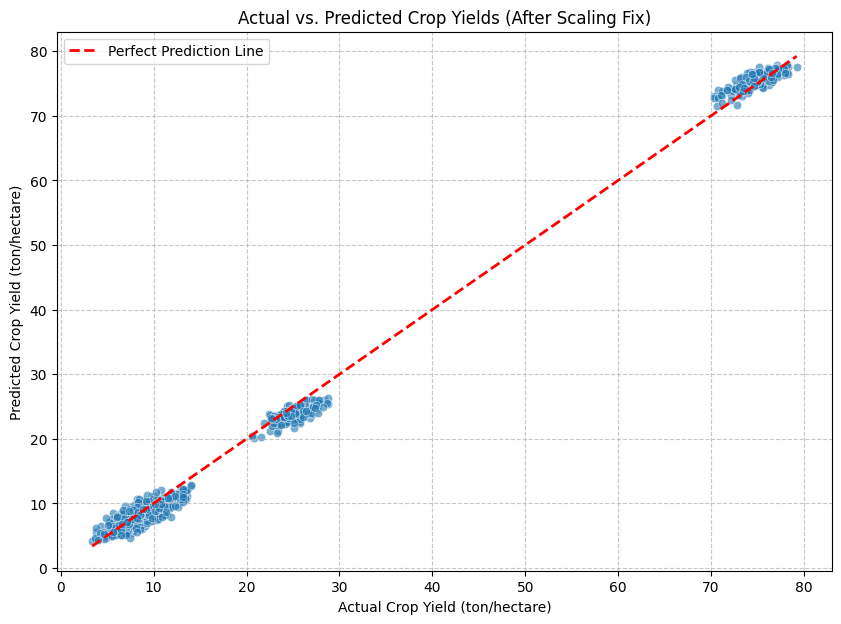

In [11]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Actual Crop Yield', y='Predicted Crop Yield', data=results_df_1, alpha=0.6)
plt.plot([results_df_1['Actual Crop Yield'].min(), results_df_1['Actual Crop Yield'].max()],
         [results_df_1['Actual Crop Yield'].min(), results_df_1['Actual Crop Yield'].max()],
         color='red', linestyle='--', lw=2, label='Perfect Prediction Line')
plt.title('Actual vs. Predicted Crop Yields (After Scaling Fix)')
plt.xlabel('Actual Crop Yield (ton/hectare)')
plt.ylabel('Predicted Crop Yield (ton/hectare)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

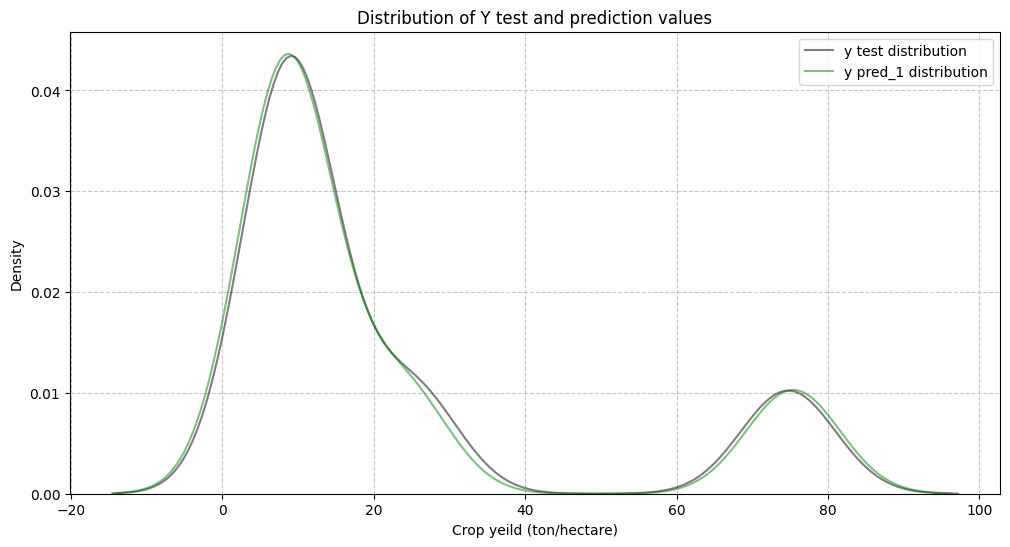

In [12]:
plt.figure(figsize=(12, 6))
sns.kdeplot(y_test_original, color='black', label='y test distribution', alpha=0.5)
sns.kdeplot(y_pred_original_1, color='green', label='y pred_1 distribution', alpha=0.5)
plt.title('Distribution of Y test and prediction values')
plt.xlabel('Crop yeild (ton/hectare)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

MODEL 2 TRAINING

In [13]:
import tensorflow as tf
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
  tf.keras.layers.Dense(25),
  tf.keras.layers.Dense(36,activation= 'relu'),
  tf.keras.layers.Dense(48,activation= 'elu'),
  # tf.keras.layers.Dropout(0.1),
  tf.keras.layers.Dense(64,activation = 'gelu'),
  tf.keras.layers.Dense(81),
  tf.keras.layers.Dense(1),
])

model_2.compile(loss='mae',
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['mae'])

print("Retraining model_2 with newly selected features...")
model_2.fit(X_train_selected, y_train, epochs=30, validation_data=(X_val_selected, y_val))

Retraining model_2 with newly selected features...
Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1830 - mae: 0.1830 - val_loss: 0.1913 - val_mae: 0.1913
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1745 - mae: 0.1745 - val_loss: 0.1920 - val_mae: 0.1920
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1706 - mae: 0.1706 - val_loss: 0.1879 - val_mae: 0.1879
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1677 - mae: 0.1677 - val_loss: 0.1693 - val_mae: 0.1693
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1635 - mae: 0.1635 - val_loss: 0.1674 - val_mae: 0.1674
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1585 - mae: 0.1585 - val_loss: 0.1675 - val_mae: 0.1675
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1557 - mae: 0.1557 - val_loss: 0.1654 - val_mae: 0.1654
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1546 - mae: 0.1546 - val_loss: 0.1621 - val_mae: 0.1621
Epoch

In [14]:
y_pred_scaled_2 = model_2.predict(X_test_selected)
model_2_results = model_2.evaluate(X_test_selected, y_test)
print(f"Test Loss: {model_2_results[0]:.4f}")
print(f"Test MAE: {model_2_results[1]:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0148 - mae: 0.0148
Test Loss: 0.0148
Test MAE: 0.0148


In [15]:
from sklearn.metrics import mean_absolute_error

with open('scalers.pkl', 'rb') as f:
    scaling_pipeline_X, y_scaler = pickle.load(f)

y_test_original = y_scaler.inverse_transform(y_test.values.reshape(-1, 1)).flatten()
y_pred_original_2 = y_scaler.inverse_transform(y_pred_scaled_2).flatten()

true_mae_2 = mean_absolute_error(y_test_original, y_pred_original_2)
print(f"Model 2 True MAE on original scale: {true_mae_2:.4f}")

results_df_2 = pd.DataFrame({
    'Actual Crop Yield': y_test_original,
    'Predicted Crop Yield': y_pred_original_2
})

display(results_df_2)

Model 2 True MAE on original scale: 1.1702


,Actual Crop Yield,Predicted Crop Yield
0,74.60,72.954460
1,24.70,23.914925
2,7.89,8.413286
3,77.25,73.529762
4,7.54,10.041308
...,...,...
995,10.84,9.532053
996,22.61,23.531635
997,10.13,9.362403
998,23.69,23.499430


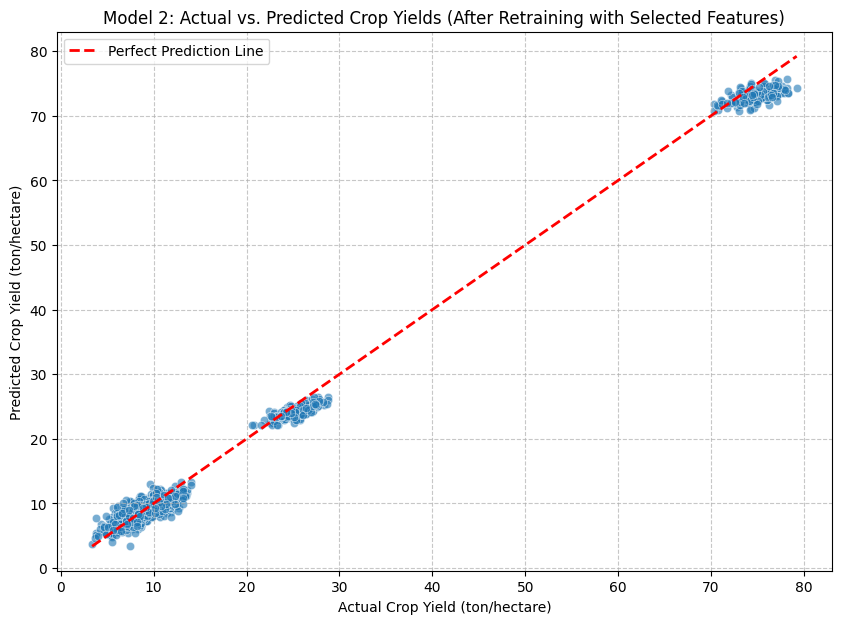

In [16]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Actual Crop Yield', y='Predicted Crop Yield', data=results_df_2, alpha=0.6)
plt.plot([results_df_2['Actual Crop Yield'].min(), results_df_2['Actual Crop Yield'].max()],
         [results_df_2['Actual Crop Yield'].min(), results_df_2['Actual Crop Yield'].max()],
         color='red', linestyle='--', lw=2, label='Perfect Prediction Line')
plt.title('Model 2: Actual vs. Predicted Crop Yields (After Retraining with Selected Features)')
plt.xlabel('Actual Crop Yield (ton/hectare)')
plt.ylabel('Predicted Crop Yield (ton/hectare)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

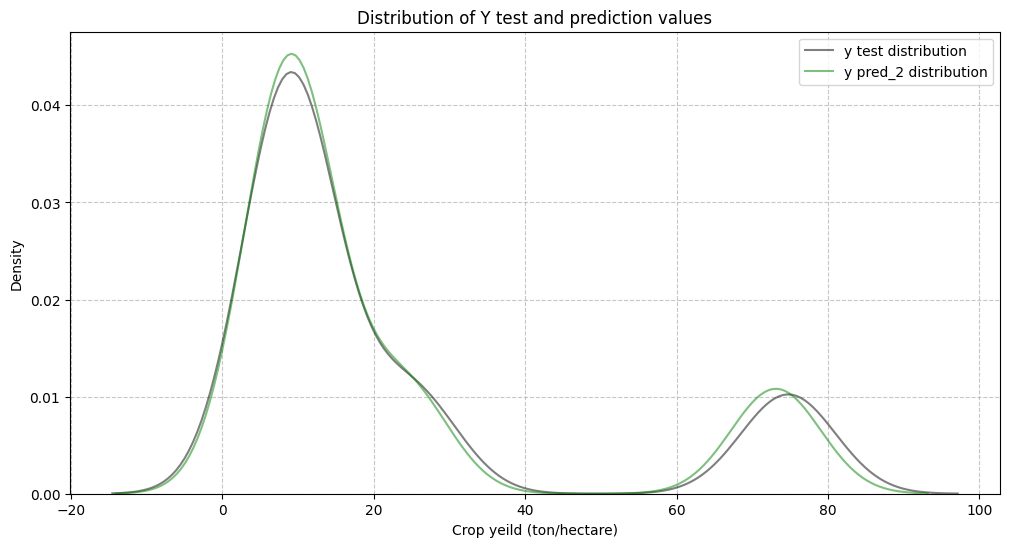

In [17]:
plt.figure(figsize=(12, 6))
sns.kdeplot(y_test_original, color='black', label='y test distribution', alpha=0.5)
sns.kdeplot(y_pred_original_2, color='green', label='y pred_2 distribution', alpha=0.5)
plt.title('Distribution of Y test and prediction values')
plt.xlabel('Crop yeild (ton/hectare)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

COMPARING THE PREDICTIONS

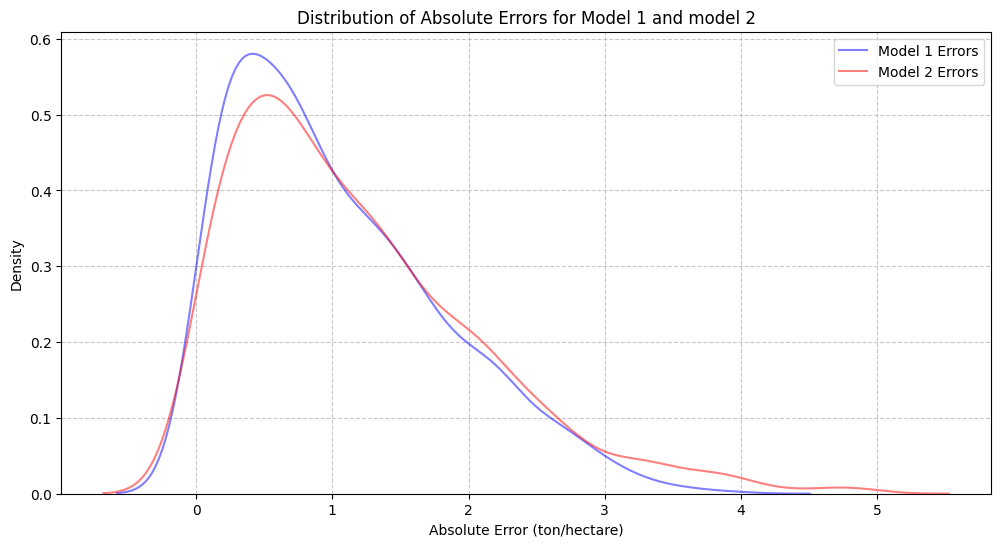

In [18]:
absolute_errors_1 = np.abs(y_test_original - y_pred_original_1)
absolute_errors_2 = np.abs(y_test_original - y_pred_original_2)

plt.figure(figsize=(12, 6))
sns.kdeplot(absolute_errors_1, color='blue', label='Model 1 Errors', alpha=0.5)
sns.kdeplot(absolute_errors_2, color='red', label='Model 2 Errors', alpha=0.5)
plt.title('Distribution of Absolute Errors for Model 1 and model 2')
plt.xlabel('Absolute Error (ton/hectare)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [19]:
with open('Model_1.pkl', 'wb') as f:
    pickle.dump((model_1), f)

In [20]:
with open('Model_2.pkl', 'wb') as f:
    pickle.dump((model_2), f)